In [8]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


In [9]:
g        = 9.81          # gravitational acceleration (m/s²)
v0       = 30.0          # launch speed (m/s)
theta_deg = 30.0         # launch angle (degrees)
theta    = np.radians(theta_deg)

vx = v0 * np.cos(theta)  # horizontal velocity component (constant throughout flight)
vy = v0 * np.sin(theta)  # initial vertical velocity component

# Analytical range: how far does it travel before hitting the ground?
# Setting y=0: x_max = 2*vx*vy / g
x_max_analytical = 2 * vx * vy / g
print(f"Launch speed : {v0} m/s at {theta_deg}°")
print(f"vx = {vx:.3f} m/s,  vy = {vy:.3f} m/s")
print(f"Analytical range (x at y=0): {x_max_analytical:.3f} m")

# The constant that appears in d²y/dx² = -g/vx²
# This is what the PINN's physics loss enforces
physics_constant = -g / (vx ** 2)
print(f"Physics constant d²y/dx² = {physics_constant:.6f}")

# Domain: x goes from 0 (launch) to x_max (landing)
x_range = (0.0, x_max_analytical)

Launch speed : 30.0 m/s at 30.0°
vx = 25.981 m/s,  vy = 15.000 m/s
Analytical range (x at y=0): 79.452 m
Physics constant d²y/dx² = -0.014533


In [10]:
class FCN(nn.Module):
    """
    Fully-connected network for PINN.
    Input:  x  (horizontal position, scalar)
    Output: y  (vertical position, scalar)
    """
    def __init__(self, N_INPUT=1, N_OUTPUT=1, N_HIDDEN=32, N_LAYERS=3):
        super().__init__()
        activation = nn.Tanh        # ← NEVER change this to ReLU for a PINN
        layers = []
        # First layer: maps input (size 1) to hidden space (size 32)
        layers.append(nn.Linear(N_INPUT, N_HIDDEN))
        layers.append(activation())
        # Hidden layers
        for _ in range(N_LAYERS - 1):
            layers.append(nn.Linear(N_HIDDEN, N_HIDDEN))
            layers.append(activation())
        # Output layer: NO activation — y can be any real number (unbounded)
        layers.append(nn.Linear(N_HIDDEN, N_OUTPUT))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

pinn = FCN(N_INPUT=1, N_OUTPUT=1, N_HIDDEN=32, N_LAYERS=3).to(device)
print(pinn)
total_params = sum(p.numel() for p in pinn.parameters())
print(f"Total trainable parameters: {total_params}")

FCN(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=32, bias=True)
    (5): Tanh()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)
Total trainable parameters: 2209


In [11]:
num_ic_points          = 1     # We only have 1 initial condition point (x=0)
num_bc_points          = 1    # Boundary points at x=x_max
num_collocation_points = 10000  # Physics enforcement points (random x in domain)

# ── IC point: x=0, y=0 ──
# requires_grad=True is MANDATORY — autograd needs this to differentiate
# the network output with respect to x
x_ic = torch.tensor([[0.0]], requires_grad=True, device=device)  # shape [1,1]
y_ic_true = torch.tensor([[0.0]], device=device)                  # y(0) = 0

# ── BC points: x = x_max, y = 0 ──
x_bc = torch.full((num_bc_points, 1), x_max_analytical,
                  requires_grad=True, device=device)
y_bc_true = torch.zeros(num_bc_points, 1, device=device)         # y(x_max) = 0

# ── Collocation points: random x ∈ [0, x_max] ──
# torch.rand gives uniform random in [0,1]; scale to [0, x_max]
x_col = (torch.rand(num_collocation_points, 1, device=device)
         * x_max_analytical)
x_col.requires_grad_(True)  # needed for d²y/dx² via autograd

print(f"IC  points shape : {x_ic.shape}")
print(f"BC  points shape : {x_bc.shape}")
print(f"Col points shape : {x_col.shape}")

IC  points shape : torch.Size([1, 1])
BC  points shape : torch.Size([1, 1])
Col points shape : torch.Size([10000, 1])


In [12]:
def analytical_y(x_vals):
    """True parabolic trajectory."""
    return (vy / vx) * x_vals - (g / (2 * vx**2)) * x_vals**2

x_plot = np.linspace(0, x_max_analytical, 300)
y_plot_true = analytical_y(x_plot)

In [13]:
def compute_losses():
    # ── IC Loss: y(0) = 0 ──────────────────────────────────────────────────
    y_pred_ic = pinn(x_ic)
    loss_ic = torch.mean((y_pred_ic - y_ic_true) ** 2)

    # ── Slope Loss: dy/dx at x=0 = vy/vx ──────────────────────────────────
    # This enforces the launch angle.
    # grad_outputs=torch.ones_like(y_pred_ic) is needed because y_pred_ic
    # is a tensor (not scalar); this sums gradients across batch dimension.
    dy_dx_ic = torch.autograd.grad(
        y_pred_ic, x_ic,
        grad_outputs=torch.ones_like(y_pred_ic),
        create_graph=True   # ← MANDATORY: keeps graph for .backward()
    )[0]
    slope_true = torch.tensor([[vy / vx]], device=device)
    loss_slope = torch.mean((dy_dx_ic - slope_true) ** 2)

    # ── BC Loss: y(x_max) = 0 ──────────────────────────────────────────────
    y_pred_bc = pinn(x_bc)
    loss_bc = torch.mean((y_pred_bc - y_bc_true) ** 2)

    # ── Physics Loss: d²y/dx² = -g/vx² ────────────────────────────────────
    # Step 1: forward pass at collocation points
    y_col = pinn(x_col)

    # Step 2: first derivative dy/dx
    dy_dx = torch.autograd.grad(
        y_col, x_col,
        grad_outputs=torch.ones_like(y_col),
        create_graph=True   # keep graph for second differentiation below
    )[0]

    # Step 3: second derivative d²y/dx²
    d2y_dx2 = torch.autograd.grad(
        dy_dx, x_col,
        grad_outputs=torch.ones_like(dy_dx),
        create_graph=True
    )[0]

    # Step 4: residual = d²y/dx² - physics_constant  (should be 0)
    residual = d2y_dx2 - physics_constant
    loss_phys = torch.mean(residual ** 2)

    return loss_ic, loss_slope, loss_bc, loss_phys

In [14]:
lambda_ic    = 1.0   # weight on y(0)=0 condition
lambda_slope = 10.0   # weight on dy/dx(0)=vy/vx condition (launch angle)
lambda_bc    = 1.0    # weight on y(x_max)=0 condition
lambda_phys  = 500.0    # weight on physics residual

num_epochs = 10000
optimizer = torch.optim.Adam(pinn.parameters(), lr=1e-3)

# Learning rate scheduler: decay LR after epoch 2000 to fine-tune
# This helps avoid oscillating around the minimum at late training stages
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2000, gamma=0.5)

# Bookkeeping
loss_ic_hist    = []
loss_slope_hist = []
loss_bc_hist    = []
loss_phys_hist  = []
loss_total_hist = []

# Snapshot epochs: capture the PINN's prediction at 4 training stages
checkpoints = [0, num_epochs // 4, num_epochs // 2, num_epochs - 1]
snapshots   = []   # list of dicts {'epoch': int, 'y_pred': array}

print("Starting training...")
print(f"{'Epoch':>6}  {'Total':>10}  {'IC':>10}  {'Slope':>10}  {'BC':>10}  {'Physics':>10}")

for epoch in range(num_epochs):
    optimizer.zero_grad()

    loss_ic, loss_slope, loss_bc, loss_phys = compute_losses()

    # Weighted total loss
    loss_total = (lambda_ic    * loss_ic
                + lambda_slope * loss_slope
                + lambda_bc    * loss_bc
                + lambda_phys  * loss_phys)

    # Backpropagate and update weights
    loss_total.backward()
    optimizer.step()
    scheduler.step()

    # Store history (detach from computation graph before converting to numpy)
    loss_ic_hist.append(loss_ic.detach().cpu().item())
    loss_slope_hist.append(loss_slope.detach().cpu().item())
    loss_bc_hist.append(loss_bc.detach().cpu().item())
    loss_phys_hist.append(loss_phys.detach().cpu().item())
    loss_total_hist.append(loss_total.detach().cpu().item())

    # Save snapshot at checkpoint epochs
    if epoch in checkpoints:
        pinn.eval()   # turn off dropout/batchnorm (not used here but good habit)
        with torch.no_grad():
            x_t = torch.tensor(x_plot, dtype=torch.float32,
                               device=device).unsqueeze(1)
            y_pred_np = pinn(x_t).cpu().numpy().squeeze()
        snapshots.append({'epoch': epoch, 'y_pred': y_pred_np})
        pinn.train()

    # Print progress every 500 epochs
    if epoch % 500 == 0:
        print(f"{epoch:>6}  {loss_total.item():>10.3e}  "
              f"{loss_ic.item():>10.3e}  {loss_slope.item():>10.3e}  "
              f"{loss_bc.item():>10.3e}  {loss_phys.item():>10.3e}")

print("Training complete.")


Starting training...
 Epoch       Total          IC       Slope          BC     Physics
     0   2.810e+00   2.356e-03   2.695e-01   1.092e-03   2.227e-04
   500   1.096e-01   9.756e-05   5.769e-04   2.477e-04   2.070e-04
  1000   1.959e-01   4.856e-05   3.819e-03   1.100e-01   9.539e-05
  1500   3.206e-02   5.641e-06   3.700e-05   3.424e-05   6.330e-05
  2000   2.256e-02   3.020e-06   2.503e-05   3.312e-06   4.460e-05
  2500   1.544e-02   1.809e-06   1.410e-05   3.323e-06   3.059e-05
  3000   1.112e-02   1.140e-06   8.535e-06   2.472e-06   2.206e-05
  3500   8.982e-03   6.221e-07   2.733e-08   4.560e-04   1.705e-05
  4000   1.315e-01   9.630e-06   1.946e-03   1.038e-01   1.657e-05
  4500   5.371e-03   3.958e-07   3.025e-06   6.993e-07   1.068e-05
  5000   4.322e-03   2.961e-07   2.200e-06   5.104e-07   8.598e-06
  5500   3.368e-03   2.219e-07   2.315e-06   1.665e-06   6.685e-06
  6000   2.627e-03   1.538e-07   1.271e-06   4.862e-08   5.228e-06
  6500   2.271e-03   1.264e-07   9.783e-0

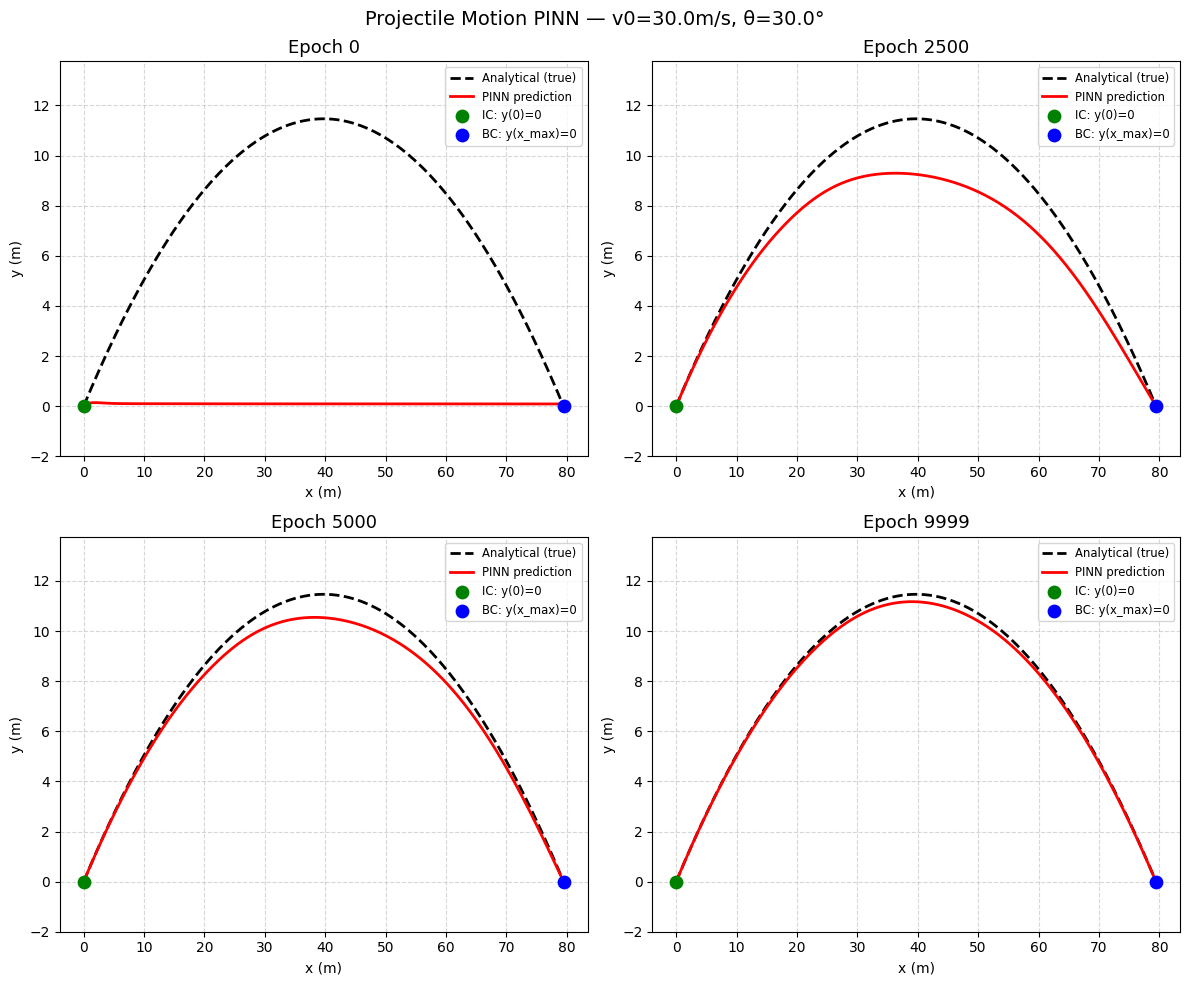

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, snap in enumerate(snapshots):
    ax = axes[idx]
    # True analytical solution
    ax.plot(x_plot, y_plot_true, 'k--', linewidth=2, label='Analytical (true)')
    # PINN prediction at this checkpoint
    ax.plot(x_plot, snap['y_pred'], 'r-', linewidth=2, label='PINN prediction')
    # Mark IC and BC points
    ax.scatter([0], [0], color='green', s=80, zorder=5, label='IC: y(0)=0')
    ax.scatter([x_max_analytical], [0], color='blue', s=80, zorder=5, label='BC: y(x_max)=0')
    ax.set_title(f"Epoch {snap['epoch']}", fontsize=13)
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_ylim(-2, y_plot_true.max() * 1.2)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize='small')

plt.suptitle(f"Projectile Motion PINN — v0={v0}m/s, θ={theta_deg}°", fontsize=14)
plt.tight_layout()
plt.show()

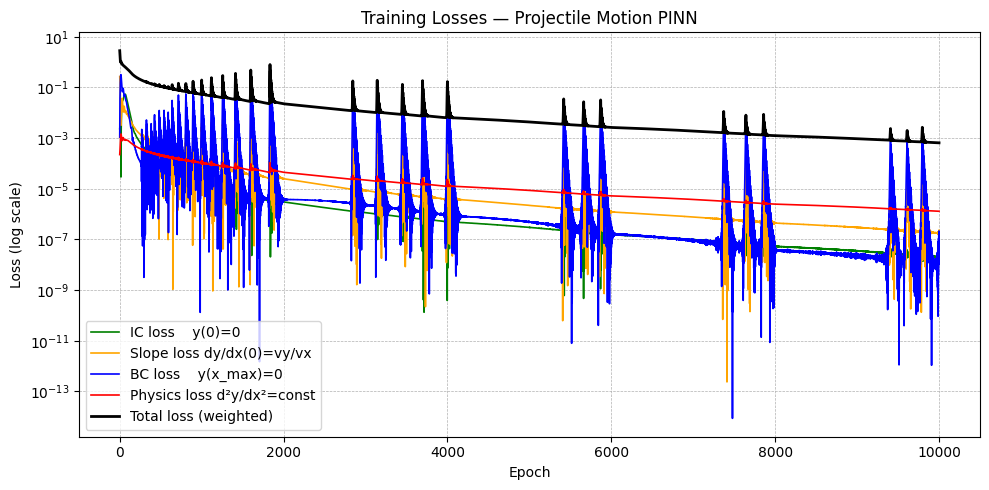

In [16]:
epochs_arr = np.arange(num_epochs)

plt.figure(figsize=(10, 5))
plt.plot(epochs_arr, loss_ic_hist,    label='IC loss    y(0)=0',       linewidth=1.2, color='green')
plt.plot(epochs_arr, loss_slope_hist, label='Slope loss dy/dx(0)=vy/vx', linewidth=1.2, color='orange')
plt.plot(epochs_arr, loss_bc_hist,    label='BC loss    y(x_max)=0',   linewidth=1.2, color='blue')
plt.plot(epochs_arr, loss_phys_hist,  label='Physics loss d²y/dx²=const', linewidth=1.2, color='red')
plt.plot(epochs_arr, loss_total_hist, label='Total loss (weighted)',   linewidth=2.0, color='black')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss (log scale)')
plt.title('Training Losses — Projectile Motion PINN')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

In [17]:
pinn.eval()
with torch.no_grad():
    x_test_t = torch.tensor(x_plot, dtype=torch.float32, device=device).unsqueeze(1)
    y_pinn_final = pinn(x_test_t).cpu().numpy().squeeze()

max_error = np.max(np.abs(y_pinn_final - y_plot_true))
rmse      = np.sqrt(np.mean((y_pinn_final - y_plot_true) ** 2))
print(f"\nFinal accuracy vs analytical solution:")
print(f"  Max absolute error : {max_error:.4f} m")
print(f"  RMSE               : {rmse:.4f} m")
print(f"  Max height (true)  : {y_plot_true.max():.4f} m")
print(f"  Relative RMSE      : {rmse / y_plot_true.max() * 100:.2f}%")


Final accuracy vs analytical solution:
  Max absolute error : 0.3234 m
  RMSE               : 0.1817 m
  Max height (true)  : 11.4678 m
  Relative RMSE      : 1.58%


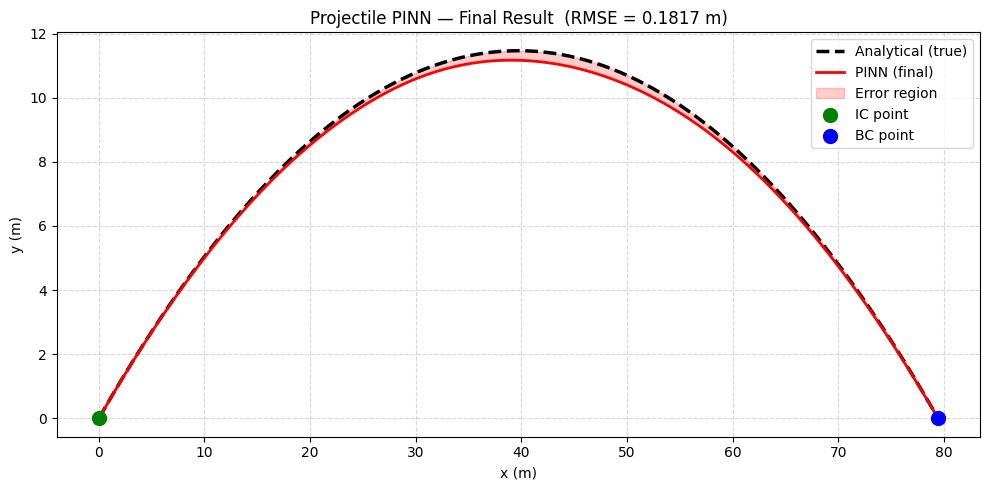

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(x_plot, y_plot_true,   'k--', linewidth=2.5, label='Analytical (true)')
plt.plot(x_plot, y_pinn_final,  'r-',  linewidth=2.0, label='PINN (final)')
plt.fill_between(x_plot,
                 y_plot_true, y_pinn_final,
                 alpha=0.2, color='red', label='Error region')
plt.scatter([0], [0], color='green', s=100, zorder=5, label='IC point')
plt.scatter([x_max_analytical], [0], color='blue', s=100, zorder=5, label='BC point')
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title(f"Projectile PINN — Final Result  (RMSE = {rmse:.4f} m)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [19]:
# Keep the trained model fixed
pinn.eval()

u0 = v0
theta0 = theta_deg

def analytical_y(x, u_test, theta_test_deg):
    theta_test = np.deg2rad(theta_test_deg)
    return (
        x * np.tan(theta_test)
        - (g * x**2) / (2 * u_test**2 * np.cos(theta_test)**2)
    )

def projectile_range(u_test, theta_test_deg):
    theta_test = np.deg2rad(theta_test_deg)
    return (u_test**2 * np.sin(2 * theta_test)) / g

def predict_pinn(x_values):
    with torch.no_grad():
        x_tensor = torch.tensor(
            x_values,
            dtype=torch.float32,
            device=device
        ).reshape(-1, 1)

        y_pred = pinn(x_tensor).cpu().numpy().squeeze()

    return y_pred

def test_case(u_test, theta_test_deg):
    x_max_original = projectile_range(u0, theta0)
    x_max_test = projectile_range(u_test, theta_test_deg)

    x_limit = min(x_max_original, x_max_test)
    x_eval = np.linspace(0, x_limit, 300)

    y_true = analytical_y(x_eval, u_test, theta_test_deg)
    y_pred = predict_pinn(x_eval)

    rmse = np.sqrt(np.mean((y_pred - y_true)**2))
    max_height = np.max(y_true)
    relative_rmse = (rmse / max_height) * 100

    return relative_rmse

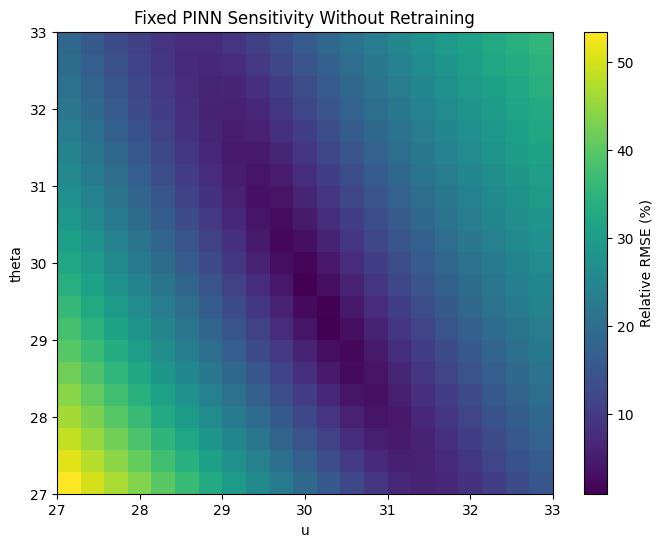

In [20]:
u_values = np.linspace(0.90 * u0, 1.10 * u0, 21)
theta_values = np.linspace(0.90 * theta0, 1.10 * theta0, 21)

error_grid = np.zeros((len(theta_values), len(u_values)))

for i, theta_test in enumerate(theta_values):
    for j, u_test in enumerate(u_values):
        error_grid[i, j] = test_case(u_test, theta_test)

plt.figure(figsize=(8, 6))
plt.imshow(
    error_grid,
    origin="lower",
    extent=[u_values[0], u_values[-1], theta_values[0], theta_values[-1]],
    aspect="auto",
    cmap="viridis"
)
plt.colorbar(label="Relative RMSE (%)")
plt.xlabel("u")
plt.ylabel("theta")
plt.title("Fixed PINN Sensitivity Without Retraining")
plt.show()

In [21]:
threshold = 5.0

valid = error_grid <= threshold

valid_indices = np.argwhere(valid)

if len(valid_indices) > 0:
    valid_u = []
    valid_theta = []

    for i, j in valid_indices:
        valid_theta.append(theta_values[i])
        valid_u.append(u_values[j])

    print("Acceptable error threshold:", threshold, "%")
    print("Valid u range:", min(valid_u), "to", max(valid_u))
    print("Valid theta range:", min(valid_theta), "to", max(valid_theta))
else:
    print("No valid region found under threshold.")

Acceptable error threshold: 5.0 %
Valid u range: 29.1 to 31.2
Valid theta range: 27.6 to 31.5
